In [36]:
import pandas as pd
import numpy as np
import seaborn as sns

from matplotlib import pyplot as plt
%matplotlib inline

In [15]:
df = pd.read_csv('housing.csv')

In [17]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [19]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [21]:
len(df)

20640

In [23]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [25]:
#convert columns to lowercase, strings with underscore
df.columns = df.columns.str.lower().str.replace(' ', '_')

string_columns = list(df.dtypes[df.dtypes == 'object'].index)

for col in string_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [27]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,near_bay
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,near_bay
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,near_bay
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,near_bay
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,near_bay


In [31]:
df.ocean_proximity.unique()

array(['near_bay', '<1h_ocean', 'inland', 'near_ocean', 'island'],
      dtype=object)

In [40]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## EDA

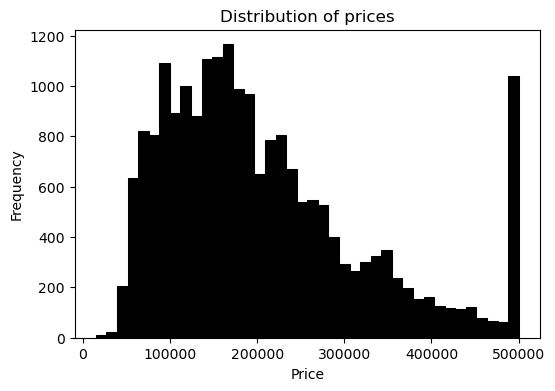

In [38]:
plt.figure(figsize=(6, 4))

sns.histplot(df.median_house_value, bins=40, color='black', alpha=1)
plt.ylabel('Frequency')
plt.xlabel('Price')
plt.title('Distribution of prices')

plt.show()

<Figure size 600x400 with 0 Axes>

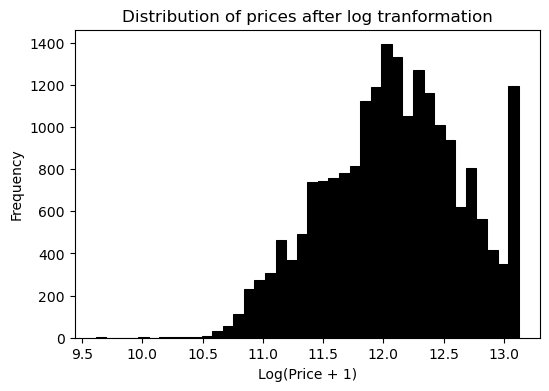

In [44]:
log_price = np.log1p(df.median_house_value)

plt.figure(figsize=(6, 4))

sns.histplot(log_price, bins=40, color='black', alpha=1)
plt.ylabel('Frequency')
plt.xlabel('Log(Price + 1)')
plt.title('Distribution of prices after log tranformation')

plt.show()

In [46]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [50]:
df.ocean_proximity.value_counts()

ocean_proximity
<1h_ocean     9136
inland        6551
near_ocean    2658
near_bay      2290
island           5
Name: count, dtype: int64

In [52]:
df.shape

(20640, 10)

## Validation Framework

In [55]:
df1 = df.copy()

In [57]:
cols = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households", 
    "median_income",
    "median_house_value"
]

df1 = df1[cols]
df1.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


In [59]:
np.random.seed(3)  # Ensures reproducibility of the shuffle

n = len(df1)  # Total number of rows in the DataFrame

n_val = int(0.2 * n)   # 20% for validation
n_test = int(0.2 * n)  # 20% for testing
n_train = n - (n_val + n_test)  # The rest (60%) for training

idx = np.arange(n)  # Create array [0, 1, ..., n-1]
np.random.shuffle(idx)  # Shuffle indices randomly

df_shuffled = df1.iloc[idx]  # Reorder the DataFrame using the shuffled indices

# Split into train, val, test sets
df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

y_train_orig = df_train.median_house_value.values
y_val_orig = df_val.median_house_value.values
y_test_orig = df_test.median_house_value.values

y_train = np.log1p(df_train.median_house_value.values)
y_val = np.log1p(df_val.median_house_value.values)
y_test = np.log1p(df_test.median_house_value.values)

del df_train['median_house_value']
del df_val['median_house_value']
del df_test['median_house_value']

## compare RMSE with and without zeros

In [70]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# with zeros


def prepareX(df):
    df = df.fillna(0) # replace blanks with 
    X = df.values
    return X
    
X_train = prepareX(df_train)

model = LinearRegression()

model.fit(X_train, y_train)

prediction = model.predict(X_train)

X_val = prepareX(df_val)
val_preds = model.predict(X_val)

print('MAE val wih 0:', mean_absolute_error(y_val, val_preds))
print("RMSE val with 0: ", mean_squared_error(y_val, val_preds, squared = False))


MAE val wih 0: 0.2574865712208252
RMSE val with 0:  0.3405153609035569


/home/franso/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [74]:
#using mean

col = ['total_bedrooms']

def prepareX_mean(df):
    mean = df[col].mean()
    df = df.fillna(mean) # replace blanks with mean
    X = df.values
    return X
    
X_train = prepareX_mean(df_train)

model = LinearRegression()

model.fit(X_train, y_train)

prediction = model.predict(X_train)

X_val = prepareX(df_val)
val_preds = model.predict(X_val)

print('MAE with mean:', mean_absolute_error(y_val, val_preds))
print("RMSE with mean: ", mean_squared_error(y_val, val_preds, squared = False))


MAE with mean: 0.25748929219849565
RMSE with mean:  0.3407339282720224


/home/franso/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## RMSE Test

In [77]:
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

X_full_train = prepareX(df_full_train)
y_full_train = np.concatenate([y_train, y_val])

X_test = prepareX(df_test)

model = LinearRegression()

model.fit(X_full_train, y_full_train)

test_preds = model.predict(X_test)

print('MAE of test:', mean_absolute_error(y_test, test_preds))
print("RMSE of test: ", mean_squared_error(y_test, test_preds, squared = False))


MAE of test: 0.2547516290521901
RMSE of test:  0.33675696329872135


/home/franso/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Using the model

In [80]:
ad = df_test.iloc[20].to_dict()
ad

{'longitude': -118.04,
 'latitude': 33.76,
 'housing_median_age': 16.0,
 'total_rooms': 2070.0,
 'total_bedrooms': 263.0,
 'population': 878.0,
 'households': 297.0,
 'median_income': 7.0879}